## Assignment 2: Eigenvalues = Variance

In this assignment I want to prove something that honestly surprised me when I first heard it — that an eigenvalue is not just some abstract number. It literally equals the variance of the data when projected onto that eigenvector's direction. Let me verify that numerically.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Step 1: Create Some Correlated 2D Data

I will generate 300 points from a correlated 2D Gaussian. The off-diagonal values in the covariance matrix create the correlation, and this is what gives the data a "tilted" shape when plotted.

In [21]:
# Define mean and covariance for correlated 2D Gaussian
mean = [0, 0]
cov = [[3, 2],   # var(x1)=3, cov(x1,x2)=2
       [2, 2]]   # cov(x2,x1)=2, var(x2)=2

n_samples = 300
X = np.random.multivariate_normal(mean, cov, size=n_samples)

print(f"Dataset shape: {X.shape}")
print(f"Sample mean (approx): {X.mean(axis=0).round(3)}")
print(f"True covariance matrix:\n{np.array(cov)}")

Dataset shape: (300, 2)
Sample mean (approx): [0.025 0.006]
True covariance matrix:
[[3 2]
 [2 2]]


## Step 2: Compute the Covariance Matrix

I will center the data first (subtract the mean) and then compute the covariance matrix. This tells me how much each pair of features varies together.

In [22]:
# Center the data (subtract mean)
X_centered = X - X.mean(axis=0)

# Compute covariance matrix manually: C = (1/n-1) * X^T X
C = np.cov(X_centered, rowvar=False)

print("Empirical Covariance Matrix:")
print(C.round(4))

Empirical Covariance Matrix:
[[2.8906 1.9188]
 [1.9188 1.8937]]


## Step 3: Find the Eigenvalues and Eigenvectors

Now I decompose the covariance matrix to get eigenvalues and eigenvectors. I sort them so the most important PC comes first.

In [23]:
eigenvalues, eigenvectors = np.linalg.eig(C)

# Sort by descending eigenvalue
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues (sorted descending):")
for i, val in enumerate(eigenvalues):
    print(f"  Lambda{i+1} = {val:.4f}")

print("\nEigenvectors (columns):")
for i in range(len(eigenvalues)):
    print(f"  v{i+1} = {eigenvectors[:, i].round(4)}")

Eigenvalues (sorted descending):
  Lambda1 = 4.3746
  Lambda2 = 0.4096

Eigenvectors (columns):
  v1 = [0.791  0.6118]
  v2 = [-0.6118  0.791 ]


## Step 4: The Key Check — Does Eigenvalue = Variance of Projection?

This is the whole point of the assignment. I will project the data onto each eigenvector and measure the variance of those projections. If the theory holds, the variance should match the eigenvalue exactly.

In [24]:
# Project data onto each eigenvector and measure variance
print("Verification: eigenvalue vs. variance of projection\n")
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    projection = X_centered @ v          # scalar projection of each point
    var_proj = np.var(projection, ddof=1)
    print(f"  PC{i+1}: Lambda{i+1} = {eigenvalues[i]:.4f}  |  Var(projection) = {var_proj:.4f}  |  Match: {np.isclose(eigenvalues[i], var_proj, atol=0.05)}")

total_variance = np.sum(eigenvalues)
print(f"\nTotal variance (sum of eigenvalues): {total_variance:.4f}")
print(f"Trace of covariance matrix:          {np.trace(C):.4f}  (should match)")

Verification: eigenvalue vs. variance of projection

  PC1: Lambda1 = 4.3746  |  Var(projection) = 4.3746  |  Match: True
  PC2: Lambda2 = 0.4096  |  Var(projection) = 0.4096  |  Match: True

Total variance (sum of eigenvalues): 4.7842
Trace of covariance matrix:          4.7842  (should match)


## Step 5: Plot the Data with the PC Arrows

Finally, I will visualise the eigenvectors on top of the data scatter. I scale each arrow by the square root of its eigenvalue so the arrow length gives a visual sense of how much variance each PC captures.

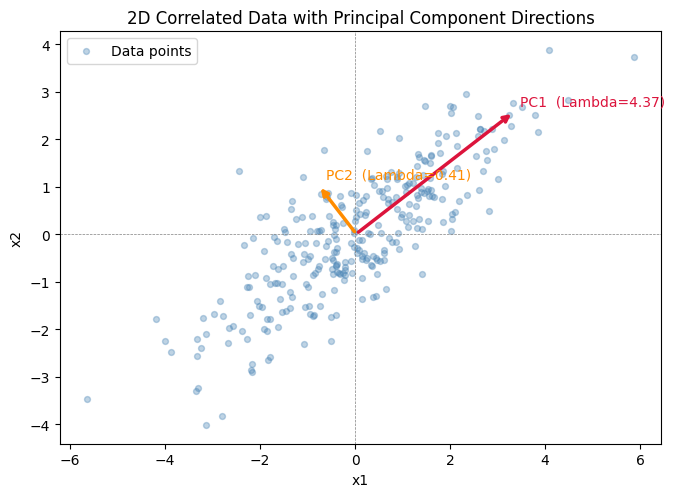

Plot saved to output/pca_assignment_2_plot.png


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(X[:, 0], X[:, 1], alpha=0.35, s=18, color='steelblue', label='Data points')

# Draw eigenvectors scaled by sqrt(eigenvalue) so length represents spread
colors = ['crimson', 'darkorange']
origin = X.mean(axis=0)
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    scale = np.sqrt(eigenvalues[i]) * 2
    ax.annotate(
        '', 
        xy=origin + scale * v, 
        xytext=origin,
        arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5)
    )
    ax.annotate(
        f'PC{i+1}  (Lambda={eigenvalues[i]:.2f})',
        xy=origin + scale * v,
        fontsize=10, color=colors[i],
        xytext=(5, 5), textcoords='offset points'
    )

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_title('2D Correlated Data with Principal Component Directions', fontsize=12)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.savefig('../output/pca_assignment_2_plot.png', dpi=150)
plt.show()
print("Plot saved to output/pca_assignment_2_plot.png")